# Lifetime GDP Growth

Charts mean annual GDP growth over people's lifetime by birth year for selected countries.

| Data                          | Source                                                                                                           | Accessed       |
| ----------------------------- | ---------------------------------------------------------------------------------------------------------------- | -------------- |
| Annual GDP growth per country | [World Bank](https://data.worldbank.org/indicator/NY.GDP.MKTP.KD.ZG?end=2024&locations=DE&start=1961&view=chart) | 16 March, 2026 |

Inspired by this [Economist chart](https://www.economist.com/britain/2026/03/05/britains-class-politics-is-back-with-a-green-twist).


In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
updated = "03/16/2026"
data = {
    "gdp-growth": pd.read_csv(
		"./data/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107.csv",
		skiprows=4
	)}

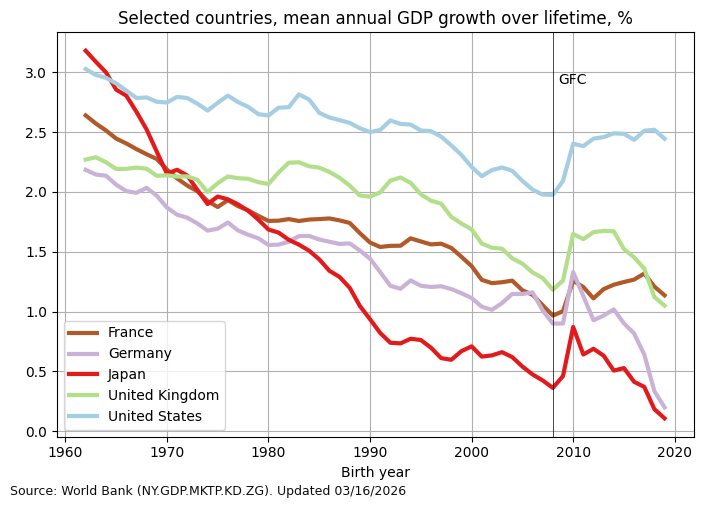

In [ ]:
countries = ["Germany", "United Kingdom", "France", "Japan", "United States"]

d = data["gdp-growth"].loc[data["gdp-growth"]["Country Name"].isin(countries)].melt(id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])[["Country Name", "Country Code", "variable", "value"]].rename(columns={"variable": "year", "Country Name": "country_name"})

d["year"] = d["year"].apply(pd.to_datetime)
d["value"] = d["value"].astype(float)

res = []

for y in range(1962, 2020):
	for c in countries:
		avg_growth = d.loc[(d["country_name"] == c) & (d["year"] >= f"{y}")]["value"].mean()
		res.append({"year": y, "avg_growth": avg_growth, "country": c})
	
result = pd.DataFrame(res).set_index(["year"]).pivot(columns="country", values="avg_growth")

fig,ax = plt.subplots(figsize=(7, 5))
result.plot(ax=ax, linewidth=3, cmap="Paired_r")
ax.set_title("Selected countries, mean annual GDP growth over lifetime, %")
ax.set_xlabel("Birth year")
ax.legend()
ax.axvline(x=2008, color="black", lw=1, zorder=10)
ax.annotate(
		zorder=200,
		text="GFC",
		xy=(2008.5, 2.9),
		horizontalalignment="left",
	)
ax.grid(axis="both")
plt.tight_layout()

ax.text(x=0, y=0, s=f"Source: World Bank (NY.GDP.MKTP.KD.ZG). Updated {updated}", transform=fig.transFigure, ha='left', fontsize=9, alpha=.95, linespacing=1.35)
plt.show()